# Optimización de carteras con LSTM, CAPM y Markowitz

Este notebook acompaña al artículo [Optimización de carteras con Machine Learning: LSTM, CAPM y Markowitz](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/) de FuzzyFrog.AI. Usa datos abiertos de Yahoo Finance, así que no depende de ningún archivo de datos externo, todo se descarga en vivo dentro del propio notebook.

## Qué vas a aprender

Este notebook no busca que memorices una receta, busca que entiendas por qué cada paso se resolvió así y con qué se reemplazaría si tu caso fuera distinto. De paso vas a tocar tres piezas que reaparecen en muchos problemas de series de tiempo y portafolios: cuándo vale la pena un LSTM frente a algo más simple, qué mide el CAPM y cómo se resuelve una optimización de Markowitz con restricciones.

## 1. Obtención de los datos: precios de activos

Datos abiertos de Yahoo Finance para diez acciones de alta capitalización:

- AAPL (Apple Inc.)
- MSFT (Microsoft Corporation)
- GOOGL (Alphabet Inc., Clase A)
- AMZN (Amazon.com Inc.)
- TSLA (Tesla, Inc.)
- META (Meta Platforms, Inc.)
- NFLX (Netflix, Inc.)
- NVDA (NVIDIA Corporation)
- JPM (JPMorgan Chase & Co.)
- JNJ (Johnson & Johnson)

Se recupera el histórico entre el 1 de enero de 2020 y el 1 de julio de 2024. Este rango queda fijo para que el notebook sea reproducible, si quieres datos más recientes solo cambia `fecha_final`.

In [24]:
from datetime import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lista de símbolos de las acciones
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM', 'JNJ']

fecha_inicial = "2020-01-01"
fecha_final = "2024-07-01"

main_data = yf.download(symbols, start=fecha_inicial, end=fecha_final)
main_data.head(5)

/tmp/ipykernel_889/3488562402.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  main_data = yf.download(symbols, start=fecha_inicial, end=fecha_final)
[*********************100%***********************]  10 of 10 completed


Price           Close                                                \
Ticker           AAPL       AMZN      GOOGL         JNJ         JPM   
Date                                                                  
2020-01-02  72.271545  94.900497  67.788933  121.338516  117.899200   
2020-01-03  71.568909  93.748497  67.434303  119.933693  116.343353   
2020-01-06  72.139198  95.143997  69.231720  119.784096  116.250832   
2020-01-07  71.799927  95.343002  69.097984  120.515572  114.274551   
2020-01-08  72.954910  94.598503  69.589813  120.498947  115.165962   

Price                                                               ...  \
Ticker            META        MSFT       NFLX      NVDA       TSLA  ...   
Date                                                                ...   
2020-01-02  207.789856  151.544266  32.980999  5.957139  28.684000  ...   
2020-01-03  206.690399  149.657288  32.590000  5.861790  29.534000  ...   
2020-01-06  210.583099  150.044144  33.583000  5.886372  30.102667  ...   
2020-01-07  211.038727  148.676010  33.075001  5.957633  31.270666  ...   
2020-01-08  213.178253  151.044189  33.925999  5.968808  32.809334  ...   

Price          Volume                                                   \
Ticker           AAPL      AMZN     GOOGL      JNJ       JPM      META   
Date                                                                     
2020-01-02  135480400  80580000  27278000  5777000  10803700  12077100   
2020-01-03  146322800  75288000  23408000  5752400  10386800  11188400   
2020-01-06  118387200  81236000  46768000  7731300  10259000  17058900   
2020-01-07  108872000  80898000  34330000  7382900  10531300  14912400   
2020-01-08  132079200  70160000  35314000  6605800   9695300  13475000   

Price                                                 
Ticker          MSFT      NFLX       NVDA       TSLA  
Date                                                  
2020-01-02  22622100  44858000  237536000  142981500  
2020-01-03  21116200  38069000  205384000  266677500  
2020-01-06  20813700  56631000  262636000  151995000  
2020-01-07  21634100  47032000  314856000  268231500  
2020-01-08  27746500  71045000  277108000  467164500  

[5 rows x 50 columns]

- Se extrae el precio ajustado de cierre.

- El precio de cierre es el último precio al cual se negoció una acción en el mercado durante una sesión de trading. Representa el valor final de la acción al cierre del mercado en un día determinado.

- El precio de cierre ajustado tiene en cuenta eventos corporativos como dividendos, splits y reverse splits, que pueden afectar el precio. El ajuste permite comparar precios históricos de manera más precisa.

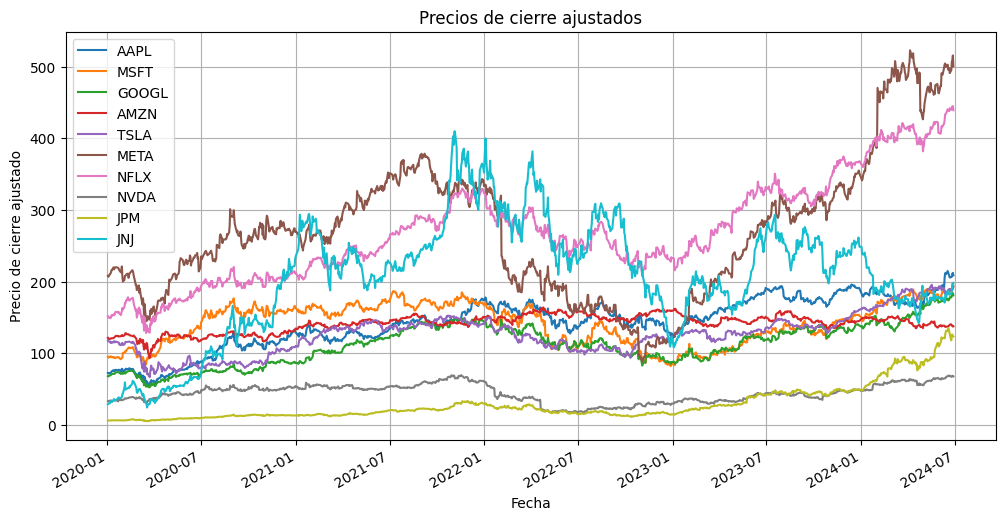

In [25]:
closing_prices = main_data['Close']

closing_prices.plot(figsize=(12, 6))
plt.title('Precios de cierre ajustados')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre ajustado')
plt.legend(symbols)
plt.grid(True)
plt.show()

## 2. Predicción de rendimientos con LSTM

### Decisión: ¿solo precio de cierre o con indicadores técnicos?

**¿Solo precio de cierre o con indicadores técnicos?**

Un modelo que solo ve el precio de cierre es más simple y tiene menos riesgo de sobreajuste, pero pierde señales de momentum y volatilidad, la predicción tiende a rezagarse detrás de movimientos bruscos del precio. Agregar indicadores técnicos da más poder predictivo porque el modelo ve momentum, volatilidad y sobrecompra o sobreventa, a cambio de más features que calcular y más NaN que manejar en las ventanas móviles.

Este notebook usa 4 indicadores técnicos calculados por acción:

1. **SMA de 20 días.** Promedio móvil simple, suaviza las fluctuaciones y ayuda a ver la tendencia general.
2. **Bandas de Bollinger (20 días, 2 desviaciones estándar).** Miden volatilidad, cuando se expanden hay más volatilidad, cuando se contraen hay menos.
3. **RSI de 14 días.** Mide momentum entre 0 y 100, valores por encima de 70 sugieren sobrecompra, por debajo de 30 sobreventa.
4. **Autocorrelación (lag 1).** Mide qué tanto se parece el precio de un día al del día anterior, ayuda a detectar patrones repetitivos.

Con menos de un año de historial, agregar indicadores es justo la opción que corre más riesgo de dejarte con muy pocas filas útiles para entrenar, porque cada ventana móvil consume filas al principio de la serie.

Explora esta decisión, con el resultado de ambas opciones, en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_indicadores)

### Arquitectura del LSTM usado aquí

Tres capas LSTM apiladas de 50 unidades cada una, con Dropout entre capas (0.2 y 0.1) para evitar que la red dependa de neuronas específicas, y una capa densa de salida con regularización L2(0.01). Se compila con el optimizador Adam y pérdida de error cuadrático medio (MSE), y se entrena 50 épocas con lotes de 32 muestras.

Primero se entrena un solo modelo, para una sola acción (AAPL), a modo de demostración. Después se repite el mismo proceso para las diez acciones, una a la vez.

In [26]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import L2
from sklearn.metrics import mean_squared_error

def calculate_technical_indicators(data, stock_name):
    data = data.copy()
    data = pd.DataFrame(data)

    data['SMA_20'] = data[stock_name].rolling(window=20).mean()

    rolling_mean = data[stock_name].rolling(window=20).mean()
    rolling_std = data[stock_name].rolling(window=20).std()
    data['BB_upper'] = rolling_mean + 2 * rolling_std
    data['BB_lower'] = rolling_mean - 2 * rolling_std

    delta = data[stock_name].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    RS = gain / loss
    data['RSI_14'] = 100 - (100 / (1 + RS))

    data = data.dropna()
    return data

def preprocess_data(data):
    data = data.dropna()
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

def build_lstm_model(input_shape):
    return Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.1),
        Dense(units=1, kernel_regularizer=L2(0.01)),
    ])

# Demostración con una sola acción (AAPL)
demo_stock = 'AAPL'
demo_train = closing_prices[demo_stock].iloc[:-30]
demo_test = closing_prices[demo_stock].iloc[-30:]

demo_train_ind = calculate_technical_indicators(demo_train, demo_stock)
demo_train_proc, demo_scaler = preprocess_data(demo_train_ind)
demo_test_ind = calculate_technical_indicators(demo_test, demo_stock)
demo_test_proc, _ = preprocess_data(demo_test_ind)

X_train_demo = demo_train_proc[:, :-1].reshape((demo_train_proc.shape[0], demo_train_proc.shape[1] - 1, 1))
y_train_demo = demo_train_proc[:, -1]
X_test_demo = demo_test_proc[:, :-1].reshape((demo_test_proc.shape[0], demo_test_proc.shape[1] - 1, 1))
y_test_demo = demo_test_proc[:, -1]

demo_model = build_lstm_model((X_train_demo.shape[1], 1))
demo_model.compile(optimizer='adam', loss='mean_squared_error')
demo_history = demo_model.fit(X_train_demo, y_train_demo, epochs=50, batch_size=32,
                               validation_data=(X_test_demo, y_test_demo), verbose=1)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1604 - val_loss: 0.1503
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0603 - val_loss: 0.1595
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0553 - val_loss: 0.1620
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0521 - val_loss: 0.1545
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0491 - val_loss: 0.1490
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0470 - val_loss: 0.1539
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0458 - val_loss: 0.1575
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0449 - val_loss: 0.1492
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0440 - val_loss: 0.1516
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0415 - val_loss: 0.1475
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0413 - val_loss: 0.1484
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0407 - val_l

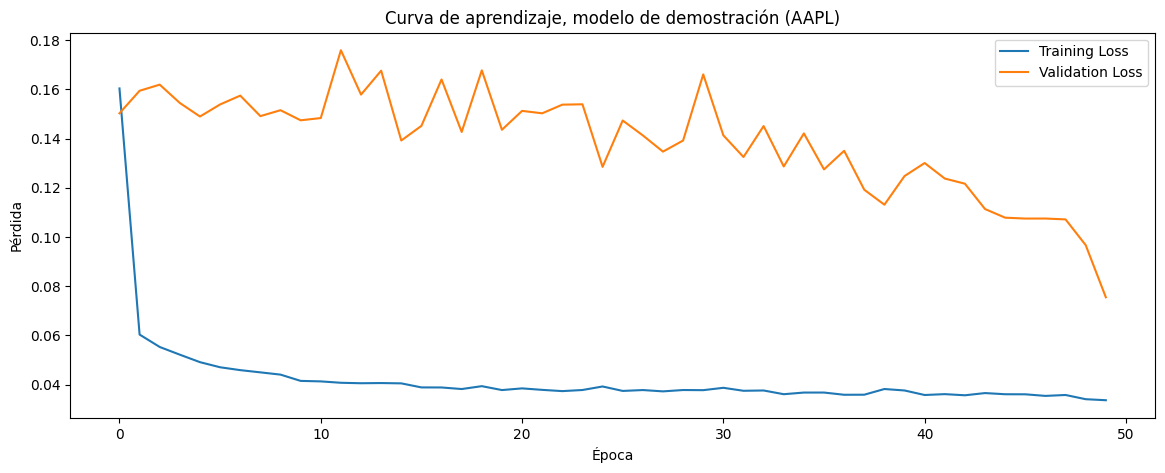

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(demo_history.history['loss'], label='Training Loss')
plt.plot(demo_history.history['val_loss'], label='Validation Loss')
plt.title('Curva de aprendizaje, modelo de demostración (AAPL)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Si la pérdida de entrenamiento y la de validación bajan juntas sin separarse demasiado, es señal de que el modelo generaliza razonablemente. Si la de validación empieza a subir mientras la de entrenamiento sigue bajando, es señal de sobreajuste, y valdría la pena reducir épocas, subir el dropout o simplificar la arquitectura.

MSE: 608.462550
MAE: 21.939630


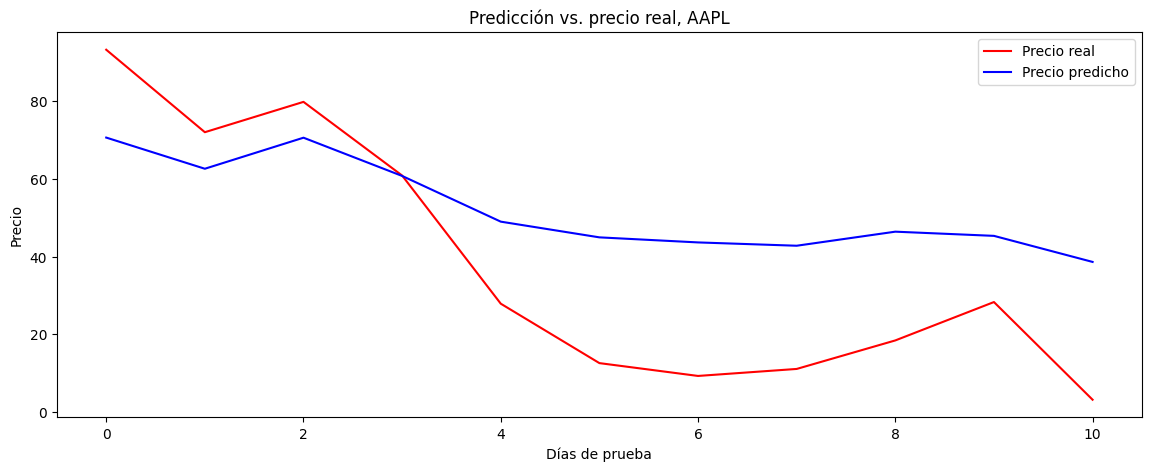

In [28]:
predicted_demo = demo_model.predict(X_test_demo, verbose=0)
predicted_demo = demo_scaler.inverse_transform(np.concatenate((X_test_demo[:, :, 0], predicted_demo), axis=1))[:, -1]
real_demo = demo_scaler.inverse_transform(np.concatenate((X_test_demo[:, :, 0], y_test_demo.reshape(-1, 1)), axis=1))[:, -1]

print(f"MSE: {mean_squared_error(real_demo, predicted_demo):.6f}")
print(f"MAE: {np.mean(np.abs(real_demo - predicted_demo)):.6f}")

plt.figure(figsize=(14, 5))
plt.plot(real_demo, color='red', label='Precio real')
plt.plot(predicted_demo, color='blue', label='Precio predicho')
plt.title(f'Predicción vs. precio real, {demo_stock}')
plt.xlabel('Días de prueba')
plt.ylabel('Precio')
plt.legend()
plt.show()

### Decisión: ¿cuántas capas LSTM y cuántas unidades?

**¿Cuántas capas LSTM y cuántas unidades?**

Una sola capa de 50 unidades entrena más rápido y es menos propensa a sobreajustar, pero puede no capturar patrones más complejos en la serie. Tres capas apiladas con Dropout, la opción usada en `build_lstm_model`, dan más capacidad de representación a costa de más tiempo de entrenamiento.

Si quisieras reemplazar el LSTM por otra arquitectura, por ejemplo un Transformer de series de tiempo, `build_lstm_model` es la única pieza que reemplazas, el resto del pipeline (CAPM, Markowitz) no se entera, porque solo espera un rendimiento esperado por activo.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-lstm_arquitectura)

### Generalizando a las diez acciones

Se repite el mismo proceso, un modelo LSTM independiente por acción, sin compartir pesos entre ellas.

In [29]:
models = {}
histories = {}
predictions = {}
reales = {}
errores = {}

for column in closing_prices.columns:
    train_data = closing_prices[column].iloc[:-30]
    test_data = closing_prices[column].iloc[-30:]

    train_ind = calculate_technical_indicators(train_data, column)
    train_proc, scaler = preprocess_data(train_ind)
    test_ind = calculate_technical_indicators(test_data, column)
    test_proc, _ = preprocess_data(test_ind)

    X_train = train_proc[:, :-1]
    y_train = train_proc[:, -1]
    X_test = test_proc[:, :-1]
    y_test = test_proc[:, -1]

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = build_lstm_model((X_train.shape[1], 1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                         validation_data=(X_test, y_test), verbose=0)

    predicted = model.predict(X_test, verbose=0)
    predicted_price = scaler.inverse_transform(np.concatenate((X_test[:, :, 0], predicted), axis=1))[:, -1]
    real_price = scaler.inverse_transform(np.concatenate((X_test[:, :, 0], y_test.reshape(-1, 1)), axis=1))[:, -1]

    models[column] = model
    histories[column] = history
    predictions[column] = predicted_price
    reales[column] = real_price
    errores[column] = {
        'mse': mean_squared_error(real_price, predicted_price),
        'mae': float(np.mean(np.abs(real_price - predicted_price))),
    }

    print(f"{column}: MSE={errores[column]['mse']:.6f}  MAE={errores[column]['mae']:.6f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AAPL: MSE=546.642527  MAE=20.084125


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AMZN: MSE=365.884806  MAE=15.507810


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

NFLX: MSE=2328.332069  MAE=40.798367


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NVDA: MSE=1302.187277  MAE=32.268846


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TSLA: MSE=511.090062  MAE=20.682326


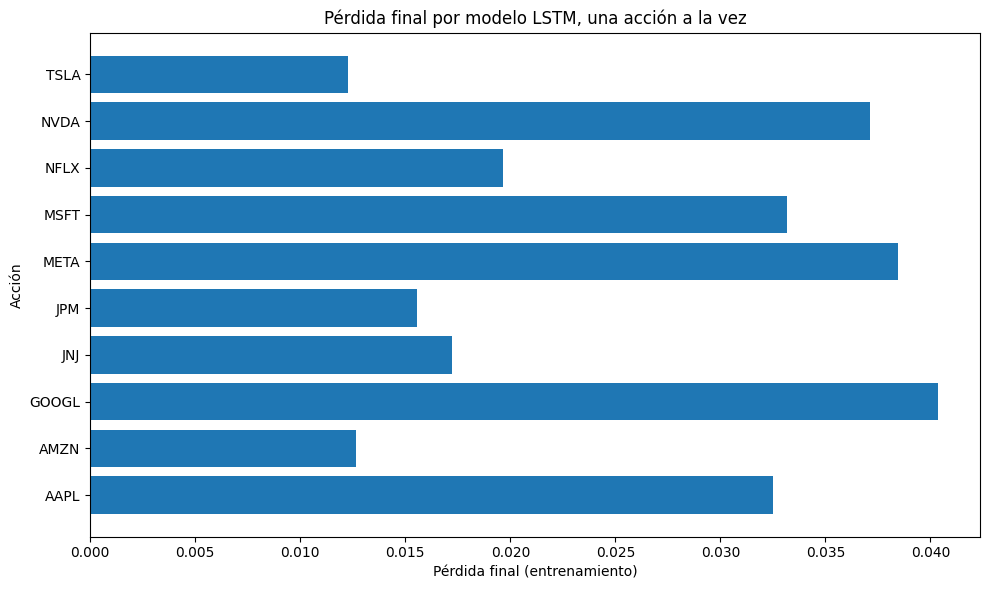

In [30]:
losses_finales = {stock: hist.history['loss'][-1] for stock, hist in histories.items()}

plt.figure(figsize=(10, 6))
plt.barh(list(losses_finales.keys()), list(losses_finales.values()))
plt.xlabel('Pérdida final (entrenamiento)')
plt.ylabel('Acción')
plt.title('Pérdida final por modelo LSTM, una acción a la vez')
plt.tight_layout()
plt.show()

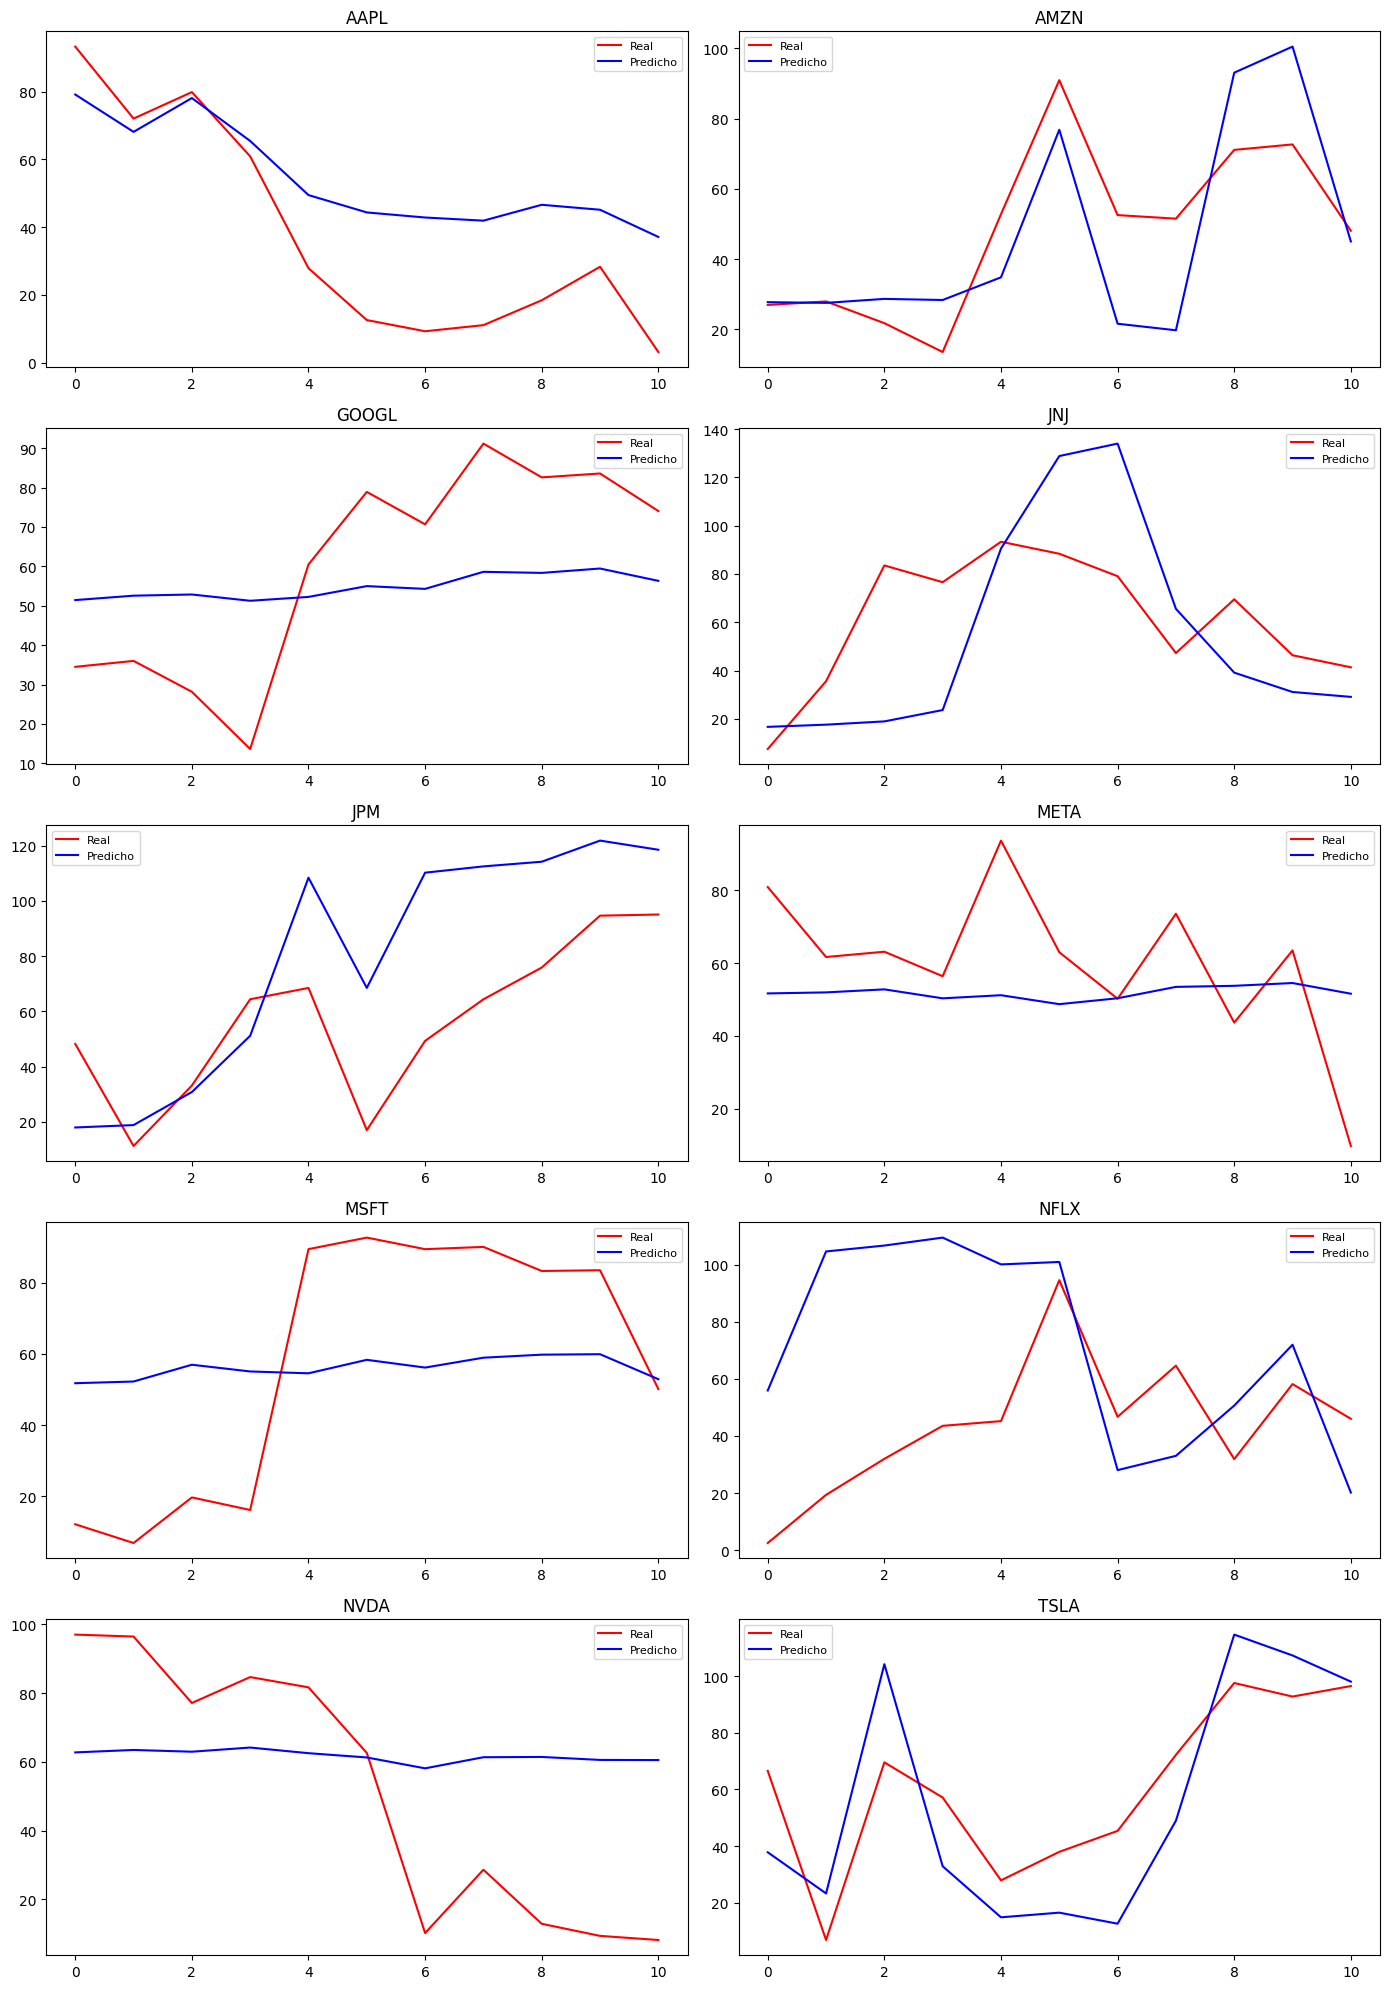

In [31]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
for ax, column in zip(axes.flat, closing_prices.columns):
    ax.plot(reales[column], color='red', label='Real')
    ax.plot(predictions[column], color='blue', label='Predicho')
    ax.set_title(column)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Selección de activos con CAPM

El Modelo de Valoración de Activos de Capital (CAPM) estima el costo de capital propio de cada acción a partir de su beta frente al mercado y una tasa libre de riesgo. Aquí se usa como filtro previo a Markowitz, se seleccionan las acciones cuyo costo de equity supera el rendimiento del mercado ajustado por la tasa libre de riesgo, y solo esas entran al optimizador.

In [32]:
er = {}
for stock, prices in predictions.items():
    er[stock] = (prices[-1] - prices[0]) / prices[0]

expected_returns_lstm = pd.Series(er, name='expected_returns')
expected_returns_lstm

,expected_returns
AAPL,-0.530830
AMZN,0.623727
GOOGL,0.094837
JNJ,0.744394
JPM,5.596130
META,-0.001524
MSFT,0.021672
NFLX,-0.638750
NVDA,-0.035586
TSLA,1.589821


### Decisión: ¿incluir todos los activos en Markowitz o filtrar antes con CAPM?

Incluir todos los activos deja que Markowitz asigne peso cero a los malos automáticamente, pero el optimizador se vuelve más inestable y sensible a errores de estimación cuando el universo es grande. Filtrar primero con CAPM reduce el universo a activos con premio por riesgo justificado, y el optimizador trabaja con un subconjunto más robusto y estable. Este notebook filtra con CAPM.

Si tu universo ya tiene menos de 10 activos, vale la pena preguntarte qué tan justificado sigue estando este filtro. Y sin un benchmark de mercado claro, por ejemplo con cripto o activos alternativos, este es el primer paso que hay que repensar, hay que decidir el proxy de mercado antes de calcular ninguna beta.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-capm_filtro)

In [33]:
from scipy import stats

# El S&P 500 se usa como proxy del mercado.
# Los rendimientos de las 10 acciones ya están disponibles en main_data, no hace falta volver a descargarlos.
returns = main_data['Close'].pct_change().dropna()
market_index = yf.download('^GSPC', start=fecha_inicial, end=fecha_final)['Close'].squeeze()
market_index = market_index.pct_change().dropna()

betas = {}
for ticker in symbols:
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_index, returns[ticker])
    betas[ticker] = slope

rf = 0.02  # tasa libre de riesgo asumida
market_return = market_index.mean() * 252

cost_of_equity = {ticker: rf + betas[ticker] * (market_return - rf) for ticker in symbols}
selected_stocks = [ticker for ticker in symbols if cost_of_equity[ticker] > market_return - rf]

print("Betas:", betas)
print("\nCosto de capital propio (CAPM):", cost_of_equity)
print("\nAcciones seleccionadas:", selected_stocks)

/tmp/ipykernel_889/2467760777.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_index = yf.download('^GSPC', start=fecha_inicial, end=fecha_final)['Close'].squeeze()
[*********************100%***********************]  1 of 1 completed

Betas: {'AAPL': np.float64(1.1868829897980666), 'MSFT': np.float64(1.1790318004727676), 'GOOGL': np.float64(1.1304467859965148), 'AMZN': np.float64(1.058588308737665), 'TSLA': np.float64(1.5120802799742352), 'META': np.float64(1.30994657330632), 'NFLX': np.float64(1.022224589528805), 'NVDA': np.float64(1.7184105821786682), 'JPM': np.float64(1.0864327236541342), 'JNJ': np.float64(0.5114351922107955)}

Costo de capital propio (CAPM): {'AAPL': np.float64(0.1619745147663737), 'MSFT': np.float64(0.1610353583336171), 'GOOGL': np.float64(0.15522363644150639), 'AMZN': np.float64(0.1466279513332284), 'TSLA': np.float64(0.2008744972186931), 'META': np.float64(0.1766953361987948), 'NFLX': np.float64(0.14227813636902797), 'NVDA': np.float64(0.2255556534816686), 'JPM': np.float64(0.14995869019350297), 'JNJ': np.float64(0.08117769306048322)}

Acciones seleccionadas: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'JPM']


## 4. Optimización de Markowitz

Los rendimientos esperados que alimentan a Markowitz son los mismos que arrojó el LSTM para cada acción, guardados en `expected_returns_lstm`. No se vuelven a calcular de otra forma, la única transformación es quedarnos solo con las acciones que pasaron el filtro CAPM.

In [34]:
er_seleccionadas = expected_returns_lstm[selected_stocks]
er_seleccionadas

,expected_returns
AAPL,-0.530830
MSFT,0.021672
GOOGL,0.094837
AMZN,0.623727
TSLA,1.589821
META,-0.001524
NFLX,-0.638750
NVDA,-0.035586
JPM,5.596130


In [35]:
from scipy.optimize import minimize

# Reutiliza los rendimientos diarios ya calculados para CAPM, filtrados a las acciones seleccionadas.
daily_returns = returns[selected_stocks]
cov_matrix = daily_returns.cov()

expected_returns = er_seleccionadas.values
num_assets = len(selected_stocks)

def objective(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},)
bounds = tuple((0, None) for _ in range(num_assets))
initial_guess = num_assets * [1.0 / num_assets]

optimized = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
w_optimal = optimized.x

print("Pesos óptimos del portafolio:")
for i, symbol in enumerate(selected_stocks):
    print(f"{symbol}: {w_optimal[i]:.4f}")

Pesos óptimos del portafolio:
AAPL: 0.1588
MSFT: 0.1545
GOOGL: 0.1477
AMZN: 0.1167
TSLA: 0.0000
META: 0.0000
NFLX: 0.0479
NVDA: 0.0000
JPM: 0.3745


### Decisión: ¿minimizar volatilidad o maximizar el ratio de Sharpe?

Minimizar volatilidad es más conservador y numéricamente más estable, es el punto más a la izquierda de la Frontera Eficiente, buena opción cuando los rendimientos esperados tienen incertidumbre, como aquí, donde vienen de una predicción LSTM. Maximizar el ratio de Sharpe busca el mejor balance retorno/riesgo, pero es más sensible a errores en esos rendimientos esperados. Este notebook minimiza volatilidad.

Si tus rendimientos esperados vinieran de guía oficial de la empresa en vez de una predicción LSTM, valdría la pena reconsiderar el objetivo. Cambiarlo es un ajuste local dentro de la llamada a `scipy.optimize.minimize`, el resto del pipeline no cambia.

Explora esta decisión en el artículo: [Explorador de decisiones](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/#explorador-markowitz_objetivo)

Retorno del portafolio óptimo: 2.0709
Riesgo (volatilidad) del portafolio óptimo: 0.0164


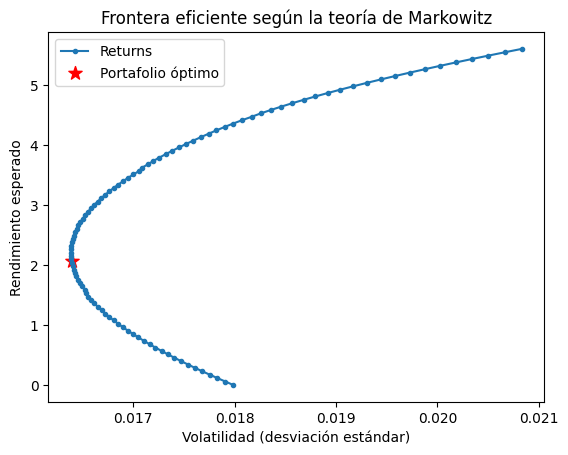

In [36]:
def portfolio_return(weights, er):
    return weights.T @ er

def portfolio_vol(weights, covmat):
    return (weights.T @ covmat @ weights) ** 0.5

def minimize_vol(target_return, er, cov):
    n = er.shape[0]
    init_guess = np.repeat(1 / n, n)
    bounds = ((0.0, 1.0),) * n
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
    return_is_target = {'type': 'eq', 'args': (er,),
                         'fun': lambda weights, er: target_return - portfolio_return(weights, er)}
    result = minimize(portfolio_vol, init_guess, args=(cov,), method='SLSQP',
                       options={'disp': False}, constraints=(weights_sum_to_1, return_is_target),
                       bounds=bounds)
    return result.x

def optimal_weights(n_points, er, cov):
    min_return = 0 if er.min() < 0 else er.min()
    target_rs = np.linspace(min_return, er.max(), n_points)
    return [minimize_vol(target_return, er, cov) for target_return in target_rs]

def plot_ef(n_points, er, cov):
    weights = optimal_weights(n_points, er, cov)
    rets = [portfolio_return(w, er) for w in weights]
    vols = [portfolio_vol(w, cov) for w in weights]
    ef = pd.DataFrame({'Returns': rets, 'Volatility': vols})
    return rets, ef.plot.line(x='Volatility', y='Returns', style='.-')

rets, ef_plot = plot_ef(100, er_seleccionadas, cov_matrix)
ef_plot.set_xlabel('Volatilidad (desviación estándar)')
ef_plot.set_ylabel('Rendimiento esperado')
ef_plot.set_title('Frontera eficiente según la teoría de Markowitz')

retorno_optimo = portfolio_return(w_optimal, er_seleccionadas)
riesgo_optimo = portfolio_vol(w_optimal, cov_matrix)

print(f"Retorno del portafolio óptimo: {retorno_optimo:.4f}")
print(f"Riesgo (volatilidad) del portafolio óptimo: {riesgo_optimo:.4f}")

ef_plot.scatter(riesgo_optimo, retorno_optimo, color='red', marker='*', s=100, label='Portafolio óptimo')
ef_plot.legend()
plt.show()

## Hallazgos y siguientes pasos

Este notebook construyó el pipeline completo: precio e indicadores técnicos, LSTM por acción, filtro CAPM y optimización de Markowitz de mínima volatilidad. El portafolio óptimo impreso arriba refleja los pesos que minimizan la volatilidad dado lo que el LSTM predijo para cada acción seleccionada.

Si quieres ir más allá:

- Revisa las 4 decisiones exploradas en este notebook, con su alternativa y el resultado que hubieras obtenido, en el [artículo completo](https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/markowitz-ml-carteras-inversion/).
- Lee la sección "Cómo adaptarlo" del artículo para ver qué cambiaría con tu propio universo de activos, tu propio proxy de mercado o tu propio objetivo de optimización.
- El repositorio en GitHub tiene el diagrama editable del pipeline y el README con las referencias académicas de cada decisión.

---
<br>
FuzzyFrog.AI · 🐸💚